# Asymmetric Feedback Model: Fitting to Experimental Data

**Model:** Rectified transcriptional feedback that only responds to protein depletion

## Mathematical Derivation

### Standard Proportional Feedback

The standard proportional feedback model regulates synthesis rate based on total protein concentration:

$$\frac{dA_n}{dt} = k_s - \delta_A \cdot A_n$$

$$\frac{dB_n}{dt} = k_s - \delta_B \cdot B_n$$

where the synthesis rate follows Michaelis-Menten-like feedback:

$$k_s = k_{s,\max} \cdot \frac{S}{S + A_n + B_n}$$

Here:
- $A_n$, $B_n$ are nuclear concentrations of RFP and GFP
- $k_{s,\max}$ is the maximum synthesis rate
- $S$ is the feedback sensitivity parameter (half-saturation constant)
- $\delta_A$, $\delta_B$ are degradation rates

### Asymmetric (One-Directional) Feedback

We modify the feedback to respond **only when total protein drops below a reference level** $\text{Total}_{\text{ref}}$:

$$k_s = \begin{cases}
k_{s,\max} \cdot \frac{S}{S + A_n + B_n} & \text{if } A_n + B_n < \text{Total}_{\text{ref}} \\
k_{s,\max} \cdot \frac{S}{S + \text{Total}_{\text{ref}}} & \text{if } A_n + B_n \geq \text{Total}_{\text{ref}}
\end{cases}$$

- **Below threshold**: Active feedback compensates for depletion (synthesis increases)
- **Above threshold**: Feedback inactive (synthesis clamped at minimum)

### Differential Degradation

To reproduce the observed higher steady-state level of RFP (A) compared to GFP (B), we allow different base degradation rates:

$$\delta_A = \delta_A^{\text{base}}$$
$$\delta_B = \delta_B^{\text{base}} + \delta_B^{\text{extra}} \text{ (when auxin is added)}$$

### Biological Interpretation

This asymmetry models a system that:
1. Protects against protein deficiency through compensatory upregulation
2. Does not suppress protein excess through negative feedback
3. May represent incomplete feedback loops or one-way regulatory mechanisms
4. Accounts for differential protein stability between RFP and GFP variants

### Parameters

**Free parameters (2):**
- $k_{s,\max}$ (maximum synthesis rate)
- $S$ (feedback sensitivity)

**Fixed parameters (from experimental measurements):**
- $\text{Total}_{\text{ref}}$ (reference threshold, set to steady-state total)
- $\delta_A^{\text{base}}$ (nuclear removal rate for RFP from bleach chase experiments)
- $\delta_B^{\text{base}}$ (calculated from steady-state ratio)
- $\delta_B^{\text{extra}}$ (20min additional degradation with auxin)

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# Import our model functions
from models import integrate_feedback_to_steady_state, simulate_feedback_trajectory
from utils import (
    save_parameters,
    load_experimental_data,
    calculate_time_averages,
    plot_data_preview,
)

# Plotting style
plt.rcParams.update({"figure.figsize": (10, 5), "font.size": 11})

## Load Experimental Data

Loaded data for: ['VEH_AUX', 'AUX_VEH']


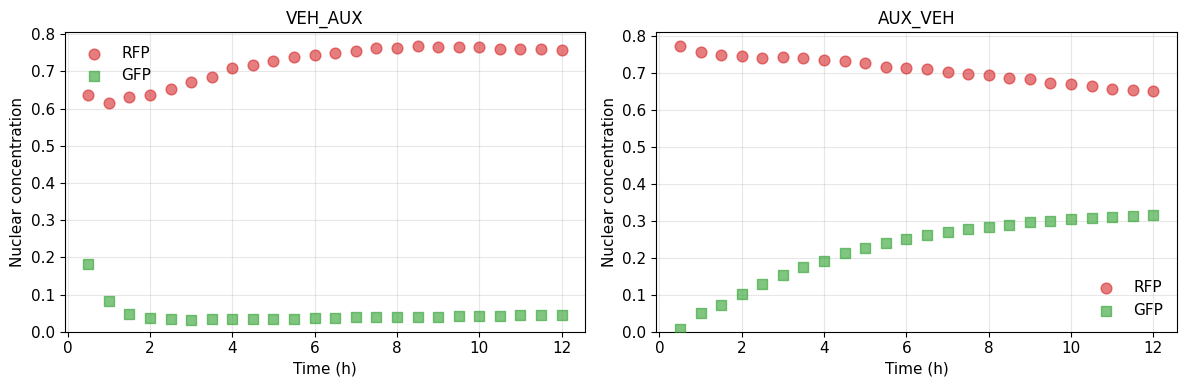

In [84]:
# Data normalization factors
RFP_NORMALIZATION = 0.5994
GFP_NORMALIZATION = 0.4153

# Load and normalize data
data_path = Path(
    "/Users/z3532965/src/blana/Scott/Modelling/ZeroOrder/data/mACmCh_LiveCellWashout_Values_ByExperiment.csv"
)
data = load_experimental_data(
    data_path, {"RFP": RFP_NORMALIZATION, "GFP": GFP_NORMALIZATION}
)

# Calculate time-averaged data
fit_conditions = ["VEH_AUX", "AUX_VEH"]
data_averaged = calculate_time_averages(data, fit_conditions)

# Use only first 12 hours
FIT_MAX_HOURS = 12.0
for code in fit_conditions:
    data_averaged[code] = data_averaged[code][
        data_averaged[code]["time"] <= FIT_MAX_HOURS
    ]

print(f"Loaded data for: {list(data_averaged.keys())}")

# Preview the data
plot_data_preview(data_averaged, fit_conditions)

## Fixed Parameters

In [85]:
# Reference level (steady-state total)
TOTAL_REF = RFP_NORMALIZATION + GFP_NORMALIZATION

# Load bleach chase data to get removal rate
bleach_chase_path = Path("../data/mACmCh_BleachChase_ByExperiment.csv")
bleach_chase_df = pd.read_csv(bleach_chase_path, index_col=0)

# Calculate DELTA_A_BASE as mean RemovalRate_perhr for VEH treatment
veh_data = bleach_chase_df[bleach_chase_df["Treatment"] == "VEH"]
DELTA_A_BASE = veh_data["RemovalRate_perhr"].mean()

# Other fixed degradation rates
DELTA_B_BASE = (
    RFP_NORMALIZATION / GFP_NORMALIZATION
) * DELTA_A_BASE  # From steady-state ratio

# Loss weighting
RFP_WEIGHT = 50.0  # VEH_AUX RFP weight (1.0 = balanced with GFP; raise to ensure buffering is well fit)
EARLY_RFP_WEIGHT = 500.0  # weight on VEH_AUX GFP points at t <= 6 h (constrains the recovery shape rather than the plateau)
EARLY_GFP_WEIGHT = 25.0  # weight on VEH_AUX GFP points at t <= 3 h (constrains the recovery shape rather than the plateau)

print("Fixed parameters:")
print(f"  Total_ref = {TOTAL_REF:.4f}")
print(
    f"  delta_A_base = {DELTA_A_BASE:.4f} hr⁻¹ (from bleach chase data, n={len(veh_data)})"
)
print(f"  delta_B_base = {DELTA_B_BASE:.4f} hr⁻¹ (t½ = {np.log(2)/DELTA_B_BASE:.1f}h)")

Fixed parameters:
  Total_ref = 1.0147
  delta_A_base = 0.1352 hr⁻¹ (from bleach chase data, n=3)
  delta_B_base = 0.1952 hr⁻¹ (t½ = 3.6h)


## Define Fitting Objective

In [86]:
def objective_function(theta, data_averaged, return_predictions=False):
    """
    Objective function for parameter fitting.

    Parameters
    ----------
    theta : array-like
        [k_s_max, S, delta_B_extra]
    data_averaged : dict
        Experimental data
    return_predictions : bool
        If True, return (loss, predictions)
    """
    k_s_max, S, delta_B_extra = theta

    if k_s_max <= 0 or S <= 0 or delta_B_extra <= 0:
        return 1e10 if not return_predictions else (1e10, None)

    # Calculate steady states
    try:
        ss_control = integrate_feedback_to_steady_state(
            k_s_max, S, TOTAL_REF, DELTA_A_BASE, DELTA_B_BASE
        )
        ss_perturbed = integrate_feedback_to_steady_state(
            k_s_max, S, TOTAL_REF, DELTA_A_BASE, DELTA_B_BASE + delta_B_extra
        )
    except:
        return 1e10 if not return_predictions else (1e10, None)

    # Simulate conditions
    conditions = {
        "VEH_AUX": (
            ss_control,
            DELTA_B_BASE + delta_B_extra,
        ),  # Start control, go to perturbed
        "AUX_VEH": (ss_perturbed, DELTA_B_BASE),  # Start perturbed, go to control
    }

    loss = 0.0
    predictions = {}

    for code, (y0, delta_B) in conditions.items():
        if code not in data_averaged:
            continue

        data = data_averaged[code]
        t_max = data["time"].max()

        try:
            traj, times = simulate_feedback_trajectory(
                k_s_max, S, TOTAL_REF, DELTA_A_BASE, delta_B, t_max, y0, n_points=100
            )
        except:
            return 1e10 if not return_predictions else (1e10, None)

        # Interpolate to data time points
        A_n_interp = np.interp(data["time"], times, traj[0])
        B_n_interp = np.interp(data["time"], times, traj[1])

        # Per-point GFP weights: emphasise the early decay that constrains the degron
        gfp_weights = np.ones(len(data))
        rfp_weights = np.ones(len(data))
        if code == "VEH_AUX":
            gfp_weights[data["time"].to_numpy() <= 3.0] = EARLY_GFP_WEIGHT
            rfp_weights[data["time"].to_numpy() <= 6.0] = EARLY_RFP_WEIGHT
            rfp_weights[data["time"].to_numpy() <= 1.0] = 1.0
            rfp_weights[data["time"].to_numpy() > 3.0] = RFP_WEIGHT

        rfp_error = np.sum(rfp_weights * (A_n_interp - data["rfp"]) ** 2)
        gfp_error = np.sum(gfp_weights * (B_n_interp - data["gfp"]) ** 2)

        loss += rfp_error + gfp_error

        if return_predictions:
            predictions[code] = {
                "time": times,
                "A_n": traj[0],
                "B_n": traj[1],
                "A_n_interp": A_n_interp,
                "B_n_interp": B_n_interp,
            }

    if return_predictions:
        return loss, predictions
    return loss

## Run Optimization

In [87]:
# Initial guess and bounds
theta0 = [0.3, 0.5, 1.8]  # [k_s_max, S, delta_B_extra]
bounds = [(0.01, 1.0), (0.01, 2.0), (0.1, 5.0)]

print("Running optimization...")
result = minimize(
    objective_function, theta0, args=(data_averaged,), method="L-BFGS-B", bounds=bounds
)

best_params_array = result.x
best_loss = result.fun

print("\n" + "=" * 60)
print("OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"Final loss: {best_loss:.4e}")
print(f"\nBest-fit parameters:")
print(f"  k_s_max = {best_params_array[0]:.4f} hr⁻¹")
print(f"  S       = {best_params_array[1]:.4f}")
print(f"  delta_B_extra = {best_params_array[2]:.4f} hr⁻¹")

Running optimization...

OPTIMIZATION COMPLETE
Final loss: 9.4453e-01

Best-fit parameters:
  k_s_max = 1.0000 hr⁻¹
  S       = 0.0899
  delta_B_extra = 2.3200 hr⁻¹


## Save Parameters

In [88]:
# Package parameters for saving
best_params = {
    "k_s_max": best_params_array[0],
    "S": best_params_array[1],
    "Total_ref": TOTAL_REF,
    "delta_A_base": DELTA_A_BASE,
    "delta_B_base": DELTA_B_BASE,
    "delta_B_extra": best_params_array[2],
}

# Save to JSON
output_path = Path("fitted_parameters/feedback_params.json")
save_parameters(best_params, output_path)
print(f"\nSaved parameters to: {output_path.resolve()}")


Saved parameters to: /Users/z3532965/src/publications/2026_POLR2A_homeostasis/Modelling/abundance_homeostasis/fitted_parameters/feedback_params.json


## Visualise Fits

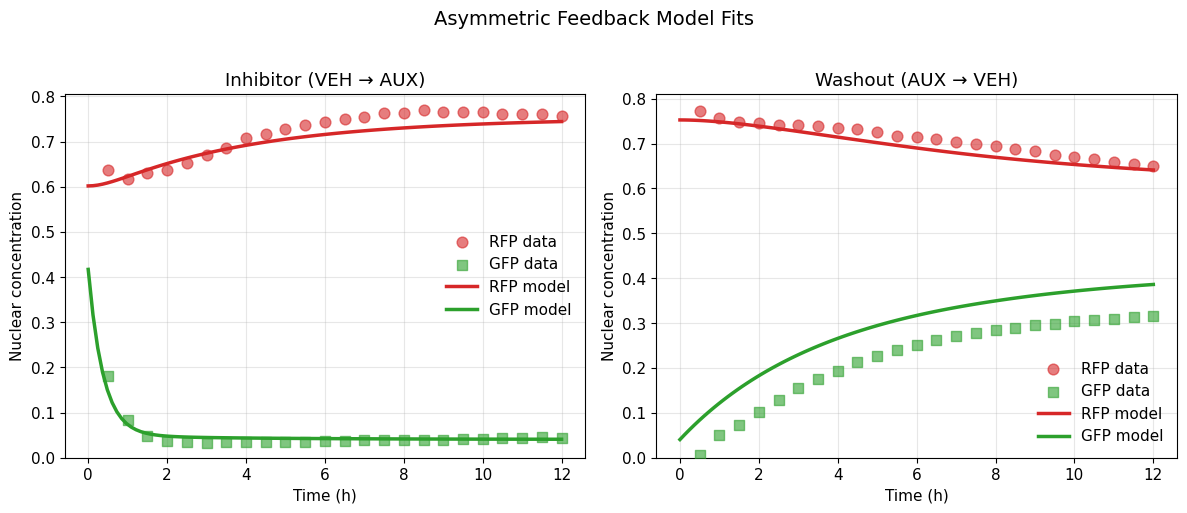

In [89]:
# Get predictions with best parameters
_, predictions = objective_function(
    best_params_array, data_averaged, return_predictions=True
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {"rfp": "#d62728", "gfp": "#2ca02c"}
titles = {"VEH_AUX": "Inhibitor (VEH → AUX)", "AUX_VEH": "Washout (AUX → VEH)"}

for ax, code in zip(axes, ["VEH_AUX", "AUX_VEH"]):
    data = data_averaged[code]
    pred = predictions[code]

    # Plot data
    ax.scatter(
        data["time"],
        data["rfp"],
        color=colors["rfp"],
        alpha=0.6,
        s=60,
        label="RFP data",
        zorder=3,
    )
    ax.scatter(
        data["time"],
        data["gfp"],
        color=colors["gfp"],
        alpha=0.6,
        s=60,
        marker="s",
        label="GFP data",
        zorder=3,
    )

    # Plot model
    ax.plot(
        pred["time"], pred["A_n"], color=colors["rfp"], linewidth=2.5, label="RFP model"
    )
    ax.plot(
        pred["time"], pred["B_n"], color=colors["gfp"], linewidth=2.5, label="GFP model"
    )

    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Nuclear concentration")
    ax.set_title(titles[code])
    ax.legend(frameon=False)
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

fig.suptitle("Asymmetric Feedback Model Fits", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("feedback_model_fits.pdf", bbox_inches="tight")
plt.show()